In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import simpest.models.simplace as simplace
import simpest.models.franchestyn as franchestyn

In [3]:
franchestyn_simulated_path = "./data/New/franchestyn_crop_model_data.csv"
simpest_simulated_path = "./data/simpest_outputs/SimulationExperimentTemplate/merged_simulation_data.csv" 
reference_path = "./data/New/reference_indiana.csv" 


franchestyn_df = pd.read_csv(franchestyn_simulated_path)
simpest_df = pd.read_csv(simpest_simulated_path)
reference_df = pd.read_csv(reference_path)

#### Disease Severity

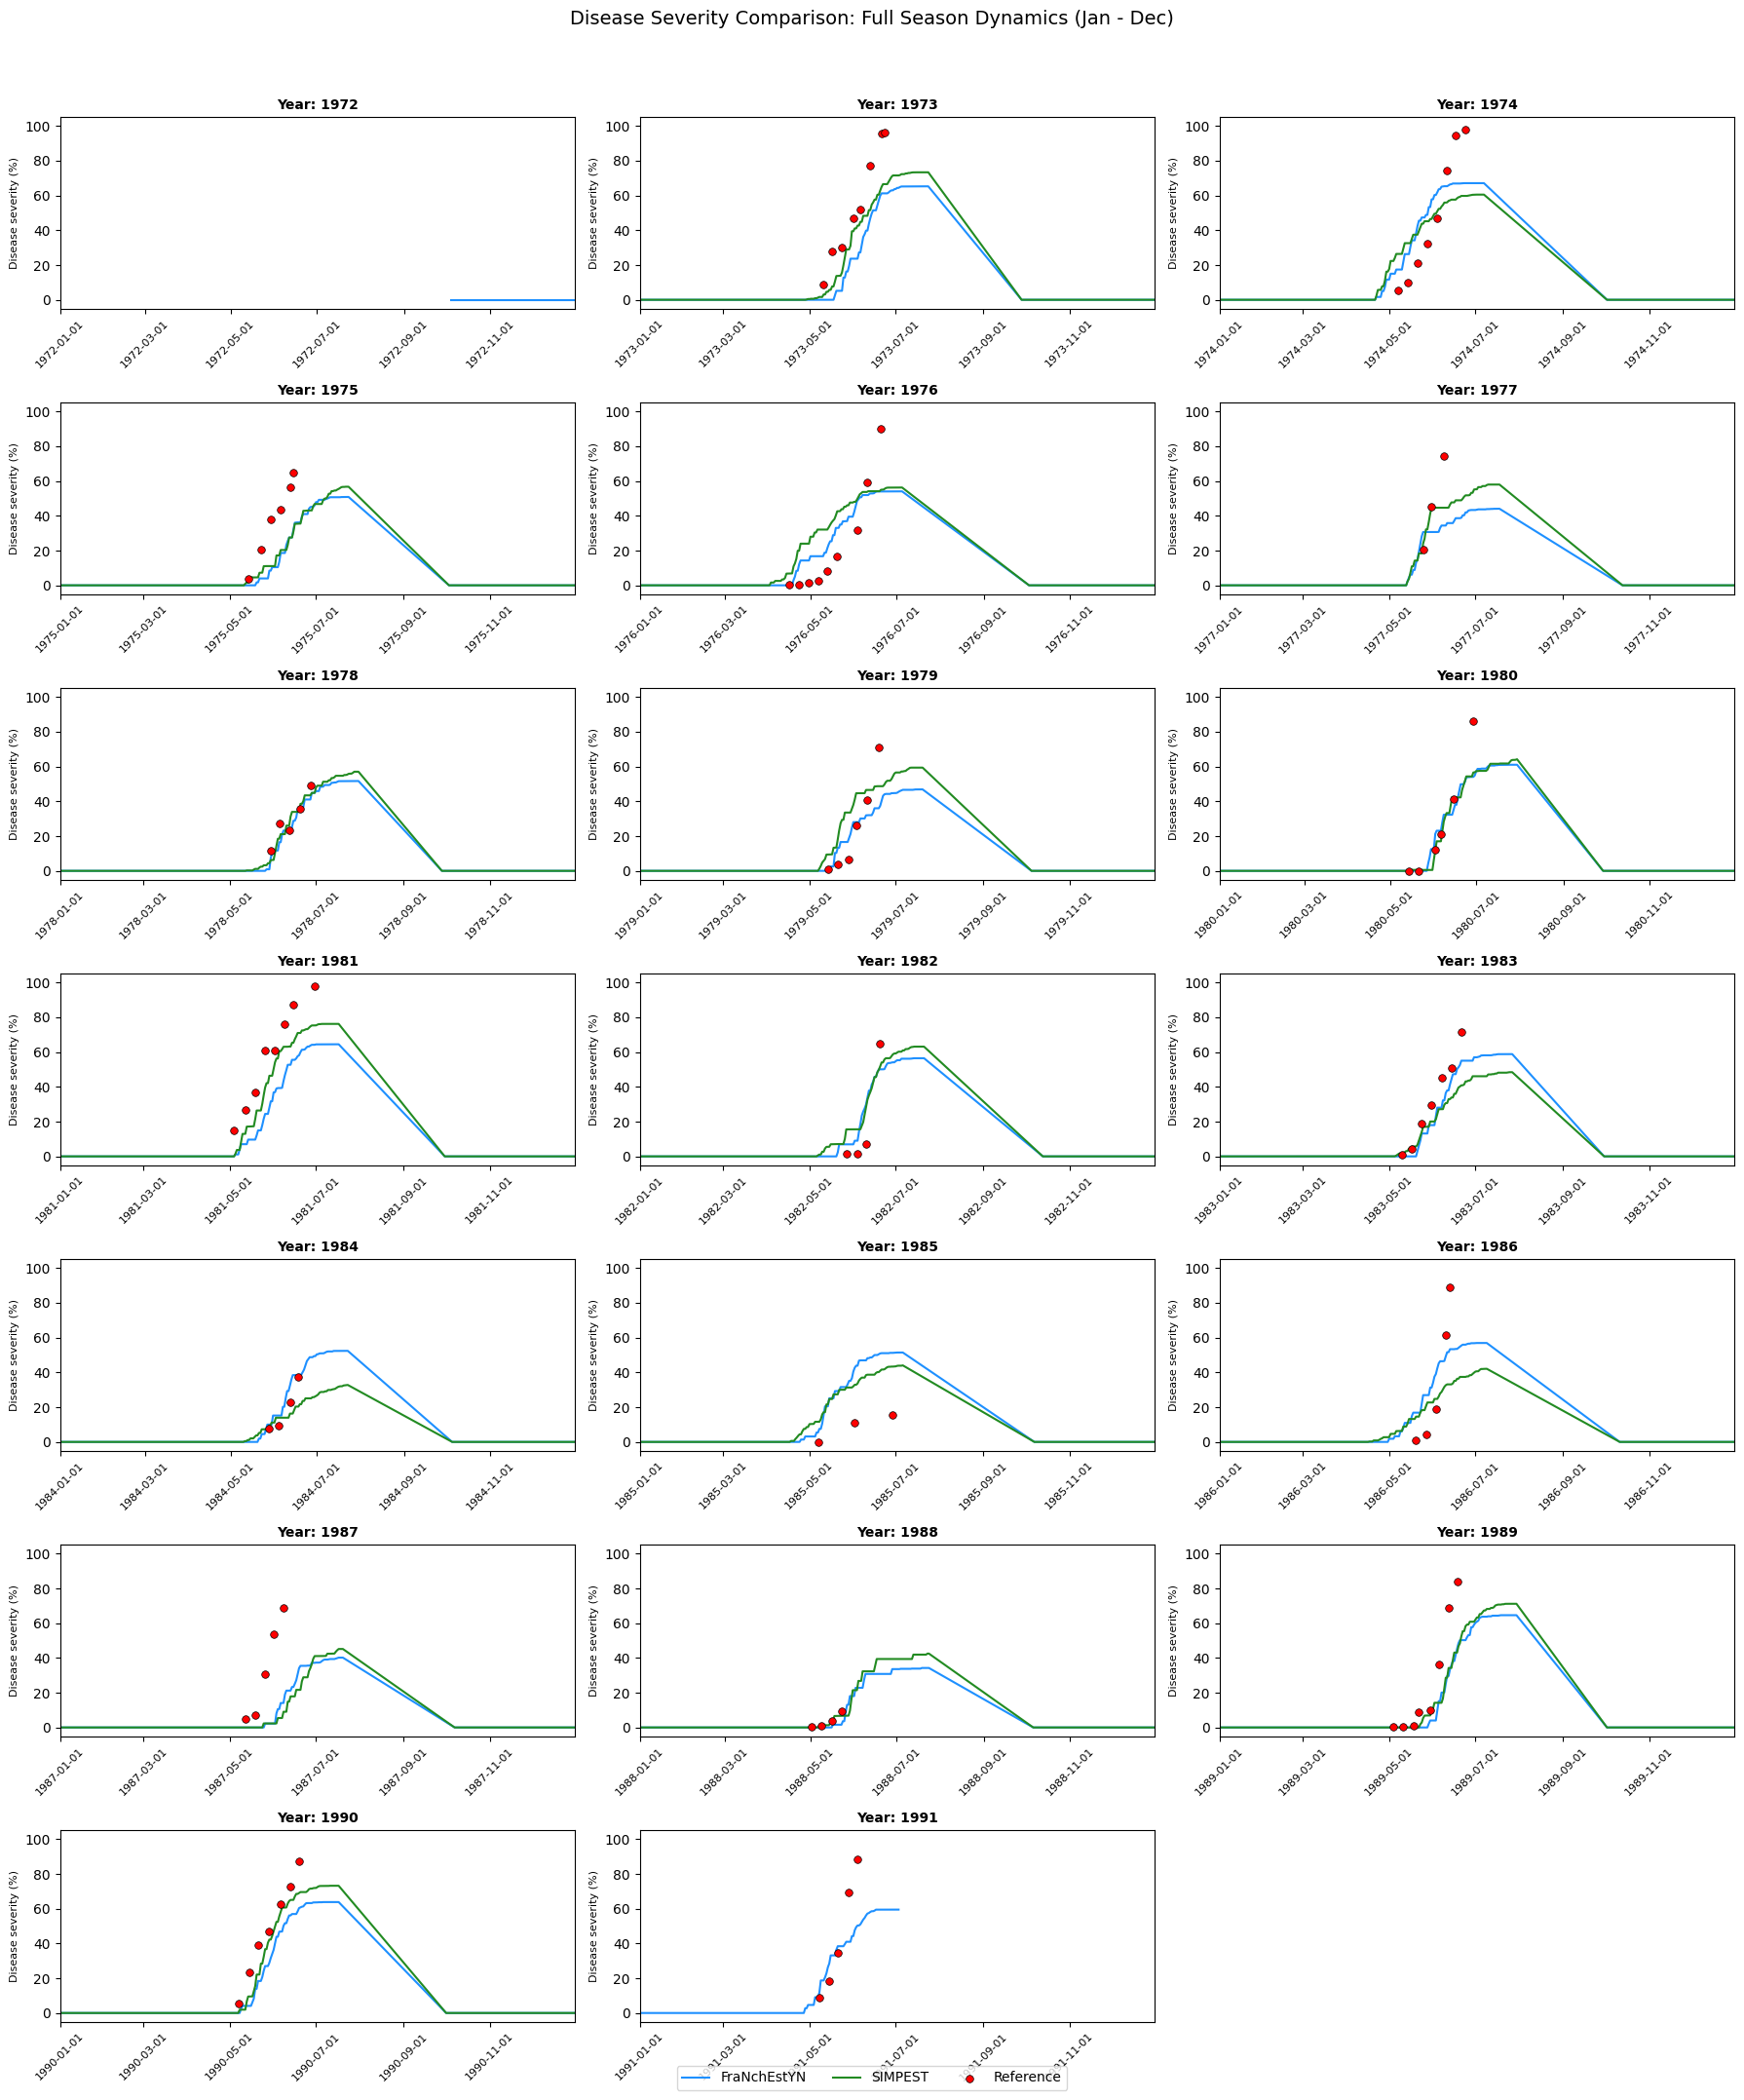

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Model writes DiseaseSeverity as a 0-1 fraction; reference Disease is 0-100 percent.
TO_PCT = 100.0

franchestyn_clean = franchestyn_df.copy()
franchestyn_clean['Date'] = pd.to_datetime(franchestyn_clean['Date'], format='mixed', dayfirst=True, errors='coerce')
franchestyn_clean['Year'] = franchestyn_clean['Date'].dt.year
franchestyn_clean['DiseaseSeverity'] = pd.to_numeric(franchestyn_clean['DiseaseSeverity'], errors='coerce') * TO_PCT
franchestyn_clean = franchestyn_clean[['Date', 'Year', 'DiseaseSeverity']].dropna(subset=['Date', 'Year'])

simpest_clean = simpest_df.copy()
simpest_clean['Date'] = pd.to_datetime(simpest_clean['Date_F'], format='mixed', dayfirst=True, errors='coerce')
simpest_clean['Year'] = simpest_clean['Date'].dt.year
simpest_clean['DiseaseSeverity'] = pd.to_numeric(simpest_clean['DiseaseSeverity_F'], errors='coerce') * TO_PCT
simpest_clean = simpest_clean[['Date', 'Year', 'DiseaseSeverity']].dropna(subset=['Date', 'Year'])

gt_clean = reference_df.copy()
gt_clean.columns = gt_clean.columns.str.lower()
gt_clean = gt_clean.dropna(subset=['year', 'doy'])
gt_clean['Date'] = pd.to_datetime(
    gt_clean['year'].astype(int).astype(str) + '-' + gt_clean['doy'].astype(int).astype(str),
    format='%Y-%j', errors='coerce'
)
gt_clean['Year'] = gt_clean['year'].astype(int)
gt_clean = gt_clean.rename(columns={'disease': 'DiseaseSeverity'})
gt_clean = gt_clean[['Date', 'Year', 'DiseaseSeverity']].dropna(subset=['Date', 'Year'])

franchestyn_clean['Source'] = 'FraNchEstYN'
simpest_clean['Source'] = 'SIMPEST'
gt_clean['Source'] = 'Reference'

master_df = pd.concat([franchestyn_clean, simpest_clean, gt_clean], ignore_index=True)
master_df.to_csv('master_disease_severity_data.csv', index=False)

years = sorted(master_df['Year'].dropna().unique())
cols = 3
rows = (len(years) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 3 * rows), sharey=False)
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    year_data = master_df[master_df['Year'] == year]

    ax.set_xlim(pd.Timestamp(f"{int(year)}-01-01"), pd.Timestamp(f"{int(year)}-12-31"))
    ax.grid(False)

    for source, color, style in zip(['FraNchEstYN', 'SIMPEST', 'Reference'],
                                    ['dodgerblue', 'forestgreen', 'red'],
                                    ['line', 'line', 'scatter']):
        subset = year_data[year_data['Source'] == source]
        if subset.empty:
            continue
        if style == 'line':
            ax.plot(subset['Date'], subset['DiseaseSeverity'],
                    label=source, color=color, linewidth=1.5, zorder=1)
        else:
            scatter_subset = subset.dropna(subset=['DiseaseSeverity'])
            ax.scatter(scatter_subset['Date'], scatter_subset['DiseaseSeverity'],
                       label=source, color=color, s=30, edgecolor='black',
                       linewidth=0.5, alpha=1.0, zorder=3)

    ax.set_title(f"Year: {int(year)}", fontsize=10, fontweight='bold')
    ax.set_ylabel('Disease severity (%)', fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_ylim(-5, 105)

for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

legend_dict = {}
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_dict.setdefault(label, handle)

fig.legend(legend_dict.values(), legend_dict.keys(), loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0))

plt.suptitle("Disease Severity Comparison: Full Season Dynamics (Jan - Dec)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
#### 